# **Channel spectrograms**

## **About**
This notebook reads DAS data over a selected time window and makes a coarse selection of the data in space with a channel selected every 500m. Then for 3 specific distances, spectrograms at associated channels are calculated (all lazy).
Those 3 spectrograms are then computed together simultaneously before plotting the results.

## **Initialization**

In [1]:
# --- load modules ---

import datetime
import matplotlib.pyplot as plt

import daspal

from dask.distributed import LocalCluster


In [2]:
### Dask cluster ###

# --- ressources setup ---
ram = 32 # in GB
cores = 8

# --- define dask cluster ---
workers = 4
mem_lim = ram / workers # mem per workers
cluster = LocalCluster(memory_limit="%fGB"%(mem_lim), n_workers=workers, 
                       threads_per_worker=int(cores/workers), processes=True)

client = cluster.get_client()

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 29.80 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46019,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38825,Total threads: 2
Dashboard: http://127.0.0.1:33353/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:33477,


## **Data access and selection**

In [9]:
%%time

# --- data selection ---
input_folder = '/your_path/OMAC_10min_sample/' # replace with your path to the data

START = datetime.datetime(2025, 9, 29, 3, 45, 0)
END = datetime.datetime(2025, 9, 29, 3, 55, 0)

# --- find files ---
filepaths = daspal.find_files(path=input_folder, start=START, end=END,
                            instr='optodas', datatype='dphi')

# --- reading data ---
meta = {"project": "OMAC", "fibre": "F5", "cable": "Catania INFN"} # add metadata
da = (
    daspal.load_data(filepaths, start=START, end=END,
                   instr='optodas', dist_sel=(0, 6000), meta=meta)
        .daspal.select_channels(spacing=500) # --- channels selection ---
)

da

CPU times: user 405 ms, sys: 94.7 ms, total: 500 ms
Wall time: 1.15 s


<xarray.DataArray 'astype-b1e26a84d18fe4fe9694578aa92ea4f4' (time: 75000,
                                                             distance: 13)> Size: 2MB
dask.array<getitem, shape=(75000, 13), dtype=int16, chunksize=(1250, 13), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 600kB 2025-09-29T03:45:00 ... 2025-09-29T...
  * distance  (distance) float32 52B 0.0 498.4 996.8 ... 5.482e+03 5.981e+03
Attributes: (12/14)
    project:      OMAC
    fibre:        F5
    cable:        Catania INFN
    experiment:   GeoInquire_DAS_exp_0925
    name:         nstrain rate
    unit:         nstrain/s
    ...           ...
    time:         1.7591174e+09
    distance:     0.0
    dt:           0.008
    dx:           498.3945
    gaugeLength:  10.213001907746815
    instrument:   {'type': 'optodas', 'parameters': {'computer': 'DASSRV129',...

## **Spectrograms calculation for selected channels**

In [5]:

# --- calculate spectrogram (lazy) ---

channels = da.sel(distance=[2000, 3000, 5000], method='nearest')

specs = channels.daspal.spectrograms(win=500)

specs

<xarray.DataArray 'astype-c38a501ea88fb85ae6d12c2c1936fe01' (distance: 3,
                                                             frequency: 251,
                                                             time: 299)> Size: 2MB
dask.array<transpose, shape=(3, 251, 299), dtype=float64, chunksize=(3, 251, 299), chunktype=numpy.ndarray>
Coordinates:
  * distance   (distance) float32 12B 1.994e+03 2.99e+03 4.984e+03
  * frequency  (frequency) float64 2kB 0.0 0.25 0.5 0.75 ... 62.0 62.25 62.5
  * time       (time) datetime64[ns] 2kB 2025-09-29T03:45:02 ... 2025-09-29T0...
Attributes: (12/14)
    project:      OMAC
    fibre:        F4
    cable:        Catania INFN
    experiment:   GeoInquire_DAS_exp_0925
    name:         spectrograms
    unit:         (nstrain/s)² Hz⁻¹
    ...           ...
    time:         1.7591174e+09
    distance:     0.0
    dt:           0.008
    dx:           498.3945
    gaugeLength:  10.213001907746815
    instrument:   {'type': 'optodas', 'parameters': {'computer': 'DASSRV129',...

In [6]:
%%time

# --- compute spectrograms ---

specs = specs.compute()


CPU times: user 289 ms, sys: 22.1 ms, total: 311 ms
Wall time: 5.33 s


## **Plotting results**

CPU times: user 130 ms, sys: 0 ns, total: 130 ms
Wall time: 128 ms


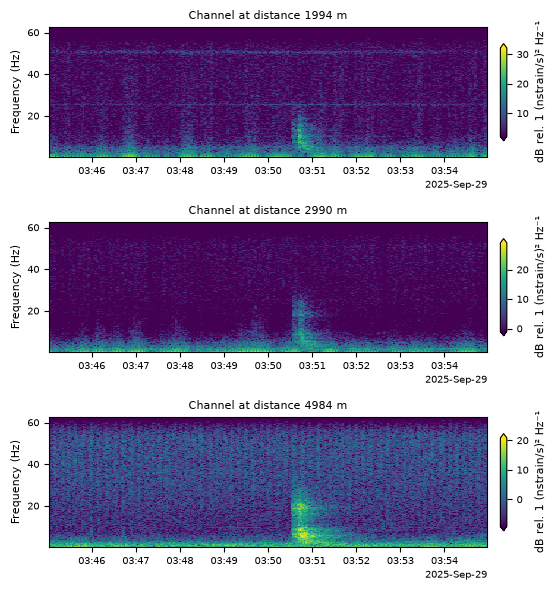

In [7]:
%%time

# --- plot spectrogram ---

fig, ax = plt.subplots(3, 1, figsize=(6, 6))

specs.isel(distance=0).daspal.plot_spectrogram(ax=ax[0], cbar=True)

specs.isel(distance=1).daspal.plot_spectrogram(ax=ax[1], cbar=True)

specs.isel(distance=2).daspal.plot_spectrogram(ax=ax[2], cbar=True)

plt.tight_layout()


## **Shutdown cluster**

In [8]:
# --- clear data on client ---
#client.cancel(da)  # free workers memory
#del da             # remove Python reference

# --- client shutdown ---
client.close()   # disconnect client
cluster.close()  # shutdown cluster gracefully